## Data Preparation

In [45]:
# importing necessary libraries
import duckdb as ddb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats

In [46]:
# creating ddb connection
con = ddb.connect("march_madness.db")

In [47]:
# reading in csv files and creating tables in ddb
con.execute("CREATE OR REPLACE TABLE teams AS SELECT * FROM read_csv_auto('../../data/clean/teams.csv')")
con.execute("CREATE OR REPLACE TABLE four_factors AS SELECT * FROM read_csv_auto('../../data/clean/four_factors.csv')")
con.execute("CREATE OR REPLACE TABLE height AS SELECT * FROM read_csv_auto('../../data/clean/height.csv')")
con.execute("CREATE OR REPLACE TABLE ratings AS SELECT * FROM read_csv_auto('../../data/clean/ratings.csv')")
con.execute("CREATE OR REPLACE TABLE tournament_games AS SELECT * FROM read_csv_auto('../../data/clean/tournament_games.csv')")
con.execute("CREATE OR REPLACE TABLE tournament_seeds AS SELECT * FROM read_csv_auto('../../data/clean/tournament_seeds.csv')")

In [48]:
# showing all tables (confirming that they were created successfully)
con.execute("SHOW TABLES").fetchall()

[('four_factors',),
 ('height',),
 ('matchups',),
 ('ratings',),
 ('teams',),
 ('tournament_games',),
 ('tournament_seeds',)]

### Subsetting Features
- Selecting features that likely contribute to outcomes from tables
- Features selected from both winners and losers, joined to form matchups table
- Difference features calculated as difference between winning team - losing team
- Features selected from 2010 onwards for complete analysis, `ratings` data starts in 2010

In [49]:
con.execute("""
    CREATE OR REPLACE TABLE matchups AS
    SELECT
        g.*,

        -- Winner ratings
        wr.RankAdjEM       AS W_RankAdjEM,
        wr.RankLuck        AS W_RankLuck,
        wr.RankSOS         AS W_RankSOS,
        wr.RankPythag      AS W_RankPythag,
        wr.RankAPL_Off     AS W_RankAPL_Off,

        -- Loser ratings
        lr.RankAdjEM       AS L_RankAdjEM,
        lr.RankLuck        AS L_RankLuck,
        lr.RankSOS         AS L_RankSOS,
        lr.RankPythag      AS L_RankPythag,
        lr.RankAPL_Off     AS L_RankAPL_Off,

        -- Winner four factors
        wf.RankeFG_Pct     AS W_RankeFG,
        wf.RankTO_Pct      AS W_RankTO,
        wf.RankOR_Pct      AS W_RankOR,
        wf.RankFT_Rate     AS W_RankFT_Rate,
        wf.RankDeFG_Pct    AS W_RankDeFG,
        wf.RankAdjOE       AS W_RankAdjOE,
        wf.RankAdjDE       AS W_RankAdjDE,
        wf.RankAdjTempo    AS W_RankAdjTempo,

        -- Loser four factors
        lf.RankeFG_Pct     AS L_RankeFG,
        lf.RankTO_Pct      AS L_RankTO,
        lf.RankOR_Pct      AS L_RankOR,
        lf.RankFT_Rate     AS L_RankFT_Rate,
        lf.RankDeFG_Pct    AS L_RankDeFG,
        lf.RankAdjOE       AS L_RankAdjOE,
        lf.RankAdjDE       AS L_RankAdjDE,
        lf.RankAdjTempo    AS L_RankAdjTempo,

        -- Winner height
        wh.AvgHgtRank      AS W_AvgHgtRank,
        wh.ExpRank         AS W_ExpRank,
        wh.HgtEffRank      AS W_HgtEffRank,
        wh.BenchRank       AS W_BenchRank,
        wh.RankContinuity  AS W_RankContinuity,

        -- Loser height
        lh.AvgHgtRank      AS L_AvgHgtRank,
        lh.ExpRank         AS L_ExpRank,
        lh.HgtEffRank      AS L_HgtEffRank,
        lh.BenchRank       AS L_BenchRank,
        lh.RankContinuity  AS L_RankContinuity,

        -- Difference features
        wr.RankAdjEM       - lr.RankAdjEM       AS Diff_AdjEM,
        wr.RankLuck        - lr.RankLuck        AS Diff_Luck,
        wr.RankSOS         - lr.RankSOS         AS Diff_SOS,
        wr.RankPythag      - lr.RankPythag      AS Diff_Pythag,
        wr.RankAPL_Off     - lr.RankAPL_Off     AS Diff_APL_Off,
        wf.RankeFG_Pct     - lf.RankeFG_Pct     AS Diff_eFG,
        wf.RankTO_Pct      - lf.RankTO_Pct      AS Diff_TO,
        wf.RankOR_Pct      - lf.RankOR_Pct      AS Diff_OR,
        wf.RankFT_Rate     - lf.RankFT_Rate     AS Diff_FT_Rate,
        wf.RankDeFG_Pct    - lf.RankDeFG_Pct    AS Diff_DeFG,
        wf.RankAdjOE       - lf.RankAdjOE       AS Diff_AdjOE,
        wf.RankAdjDE       - lf.RankAdjDE       AS Diff_AdjDE,
        wf.RankAdjTempo    - lf.RankAdjTempo    AS Diff_AdjTempo,
        wh.AvgHgtRank      - lh.AvgHgtRank      AS Diff_Hgt,
        wh.ExpRank         - lh.ExpRank          AS Diff_Exp,
        wh.HgtEffRank      - lh.HgtEffRank      AS Diff_HgtEff,
        wh.BenchRank       - lh.BenchRank        AS Diff_Bench,
        wh.RankContinuity  - lh.RankContinuity   AS Diff_Continuity

    FROM tournament_games g

    INNER JOIN ratings      wr ON g.WTeamSeason = wr.TeamSeason
    INNER JOIN four_factors wf ON g.WTeamSeason = wf.TeamSeason
    INNER JOIN height       wh ON g.WTeamSeason = wh.TeamSeason

    INNER JOIN ratings      lr ON g.LTeamSeason = lr.TeamSeason
    INNER JOIN four_factors lf ON g.LTeamSeason = lf.TeamSeason
    INNER JOIN height       lh ON g.LTeamSeason = lh.TeamSeason

    WHERE g.Season >= 2010 AND g.Season < 2025
""")

In [50]:
# creating dataframe from matchups table for analysis
matchups_df = con.execute("SELECT * FROM matchups").fetchdf()

In [51]:
# viewing the matchups table
con.execute("SELECT * FROM matchups LIMIT 5").fetchdf()

,GameID,Season,WTeamID,WScore,LTeamID,LScore,WSeed,WTeamName,LSeed,LTeamName,...,Diff_FT_Rate,Diff_DeFG,Diff_AdjOE,Diff_AdjDE,Diff_AdjTempo,Diff_Hgt,Diff_Exp,Diff_HgtEff,Diff_Bench,Diff_Continuity
0,468,2010,1181,73,1115,44,1,Duke,16,Arkansas Pine Bluff,...,149,-34,-302,-102,14,-251,-102,-255,193,75
1,508,2010,1181,78,1124,71,1,Duke,3,Baylor,...,-56,-13,-4,-38,-6,-19,-35,5,-1,-111
2,512,2010,1181,61,1139,59,1,Duke,5,Butler,...,142,-61,-48,-2,-57,-236,-43,-288,-4,109
3,484,2010,1243,84,1140,72,2,Kansas St.,7,BYU,...,-123,11,5,-25,21,73,-39,-29,77,18
4,491,2010,1181,68,1143,53,1,Duke,8,California,...,-77,-137,-2,-71,122,-146,13,-106,54,93


## EDA

In [52]:
# removing 16 seed v 16 seed matchups (first four, no upsets possible)
matchups_df = matchups_df[~((matchups_df.WSeed == 16) & (matchups_df.LSeed == 16))]

# checking the shape of the matchups dataframe and printing out the difference features
diff_cols = [c for c in matchups_df.columns if c.startswith("Diff_")]
print(f"\nShape: {matchups_df.shape}")
print(f"Diff features ({len(diff_cols)}): {diff_cols}")


Shape: (902, 69)
Diff features (18): ['Diff_AdjEM', 'Diff_Luck', 'Diff_SOS', 'Diff_Pythag', 'Diff_APL_Off', 'Diff_eFG', 'Diff_TO', 'Diff_OR', 'Diff_FT_Rate', 'Diff_DeFG', 'Diff_AdjOE', 'Diff_AdjDE', 'Diff_AdjTempo', 'Diff_Hgt', 'Diff_Exp', 'Diff_HgtEff', 'Diff_Bench', 'Diff_Continuity']


### Checking that data types are all correct, no missing values in important fields

In [53]:
# there should be no missing data in difference features
null_counts = matchups_df[diff_cols].isnull().sum()
if null_counts.sum() > 0:
    print("\nNull values found in difference features:")
    print(null_counts[null_counts > 0])
else:
    print("\nNo null values found in difference features")

# diff cols should be numeric
diff_types = matchups_df[diff_cols].dtypes
if (diff_types == "int64").all():
    print("\nAll difference features are of type int64")
else:
    print("\nDifference features have varying data types:")
    print(diff_types)

# 'Upset' column should be binary (0 or 1) and of type int64
if (matchups_df['Upset'].dtype == 'int64' and matchups_df['Upset'].isin([0, 1]).all()):
    print("\nUpset column is binary")
else: 
    print("\nUpset column is not binary or not of type int64")


No null values found in difference features

All difference features are of type int64

Upset column is binary


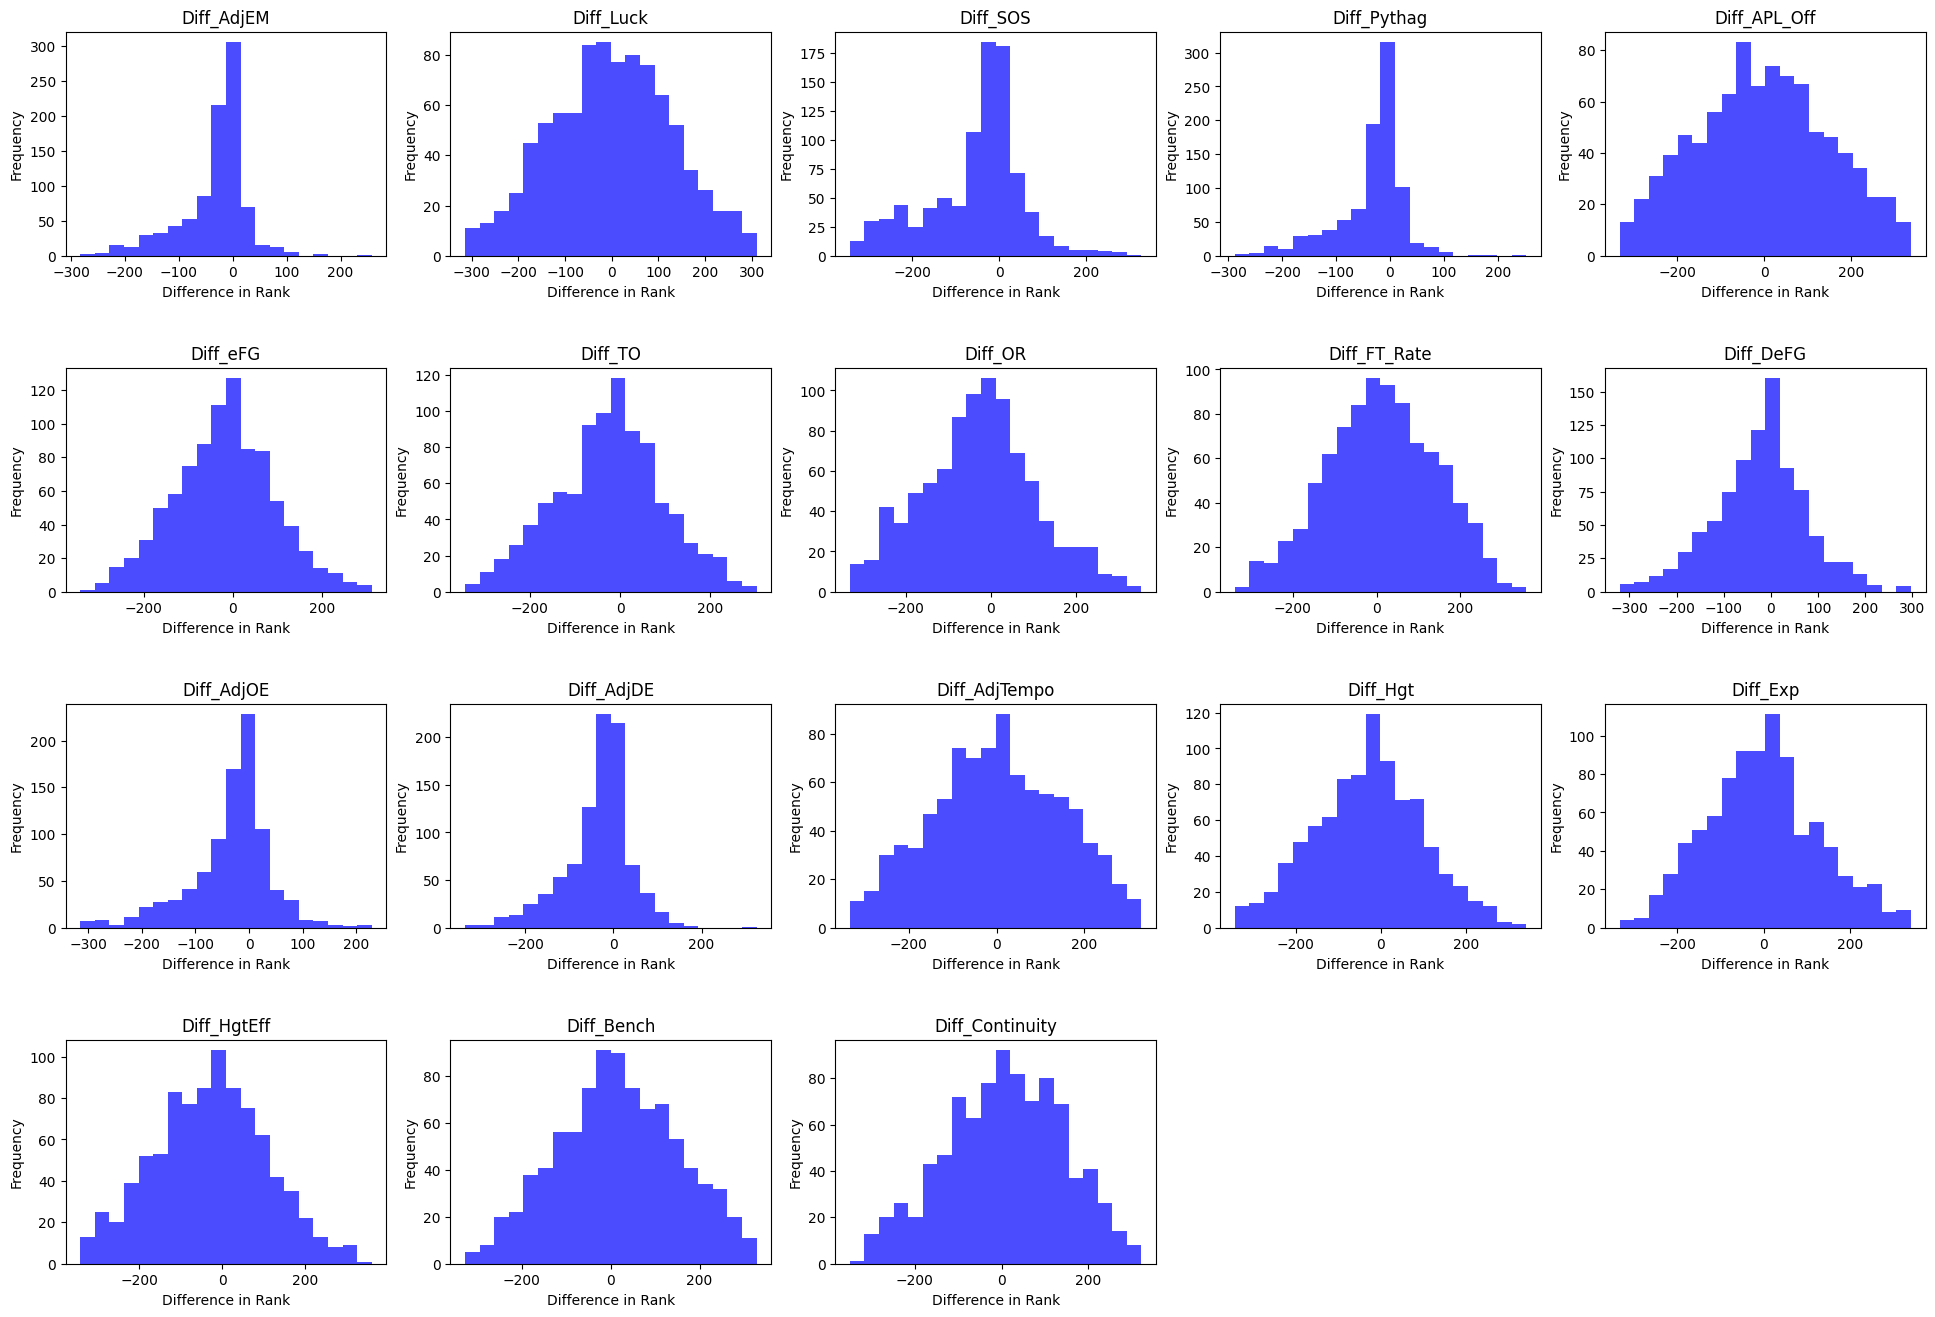

In [54]:
# generating histograms for difference features in one plot
num_cols = len(diff_cols)
cols_per_row = 5
num_rows = (num_cols + cols_per_row - 1) // cols_per_row
plt.figure(figsize=(24, num_rows * 4))
for i, col in enumerate(diff_cols):
    plt.subplot(num_rows, cols_per_row, i + 1)
    plt.hist(matchups_df[col], bins=20, color='blue', alpha=0.7)
    # adding vertical padding for space between plots
    plt.subplots_adjust(hspace=0.5)  # Adjust the value as needed for more or less space
    plt.title(col)
    plt.xlabel('Difference in Rank')
    plt.ylabel('Frequency')

- Diff AdjEM, AdjDE, AdjOE, SOS, and Pythag are pretty skewed
- This indicates that they are the biggest difference between teams that win and lose
- Must be conscious of this in feature selection and analysis

## Feature Selection

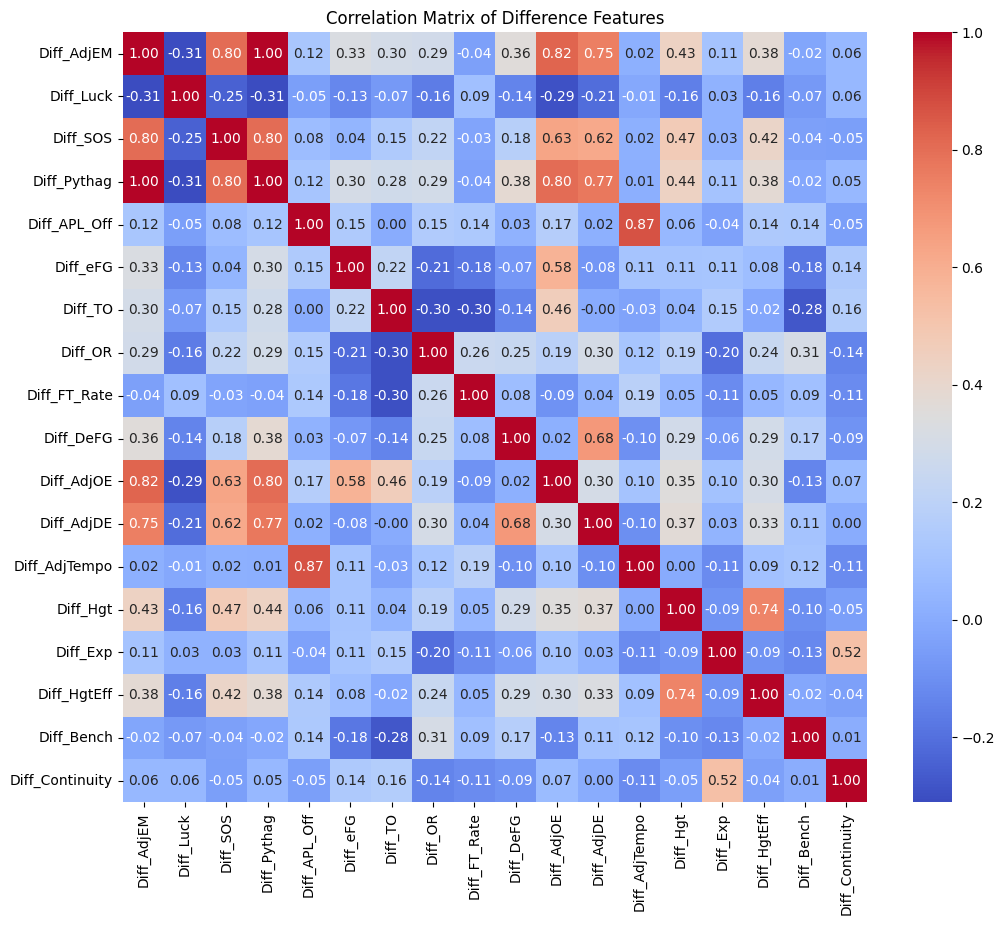

In [55]:
# correlation matrix of features
plt.figure(figsize=(12, 10))
sns.heatmap(matchups_df[diff_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Difference Features")
plt.show()

Not including highly correlated features in model
- Removing ADJ_EM as it is calculated based off of offensive and defensive efficiency
- Removing Pythag because it is calculated based off of efficiency as well
- Removing diff_hgt because effective height is highly correlated and more telling
- Removing average possession length because it is highly correlated with tempo 

In [56]:
features = [
    # Ratings
    "Diff_Luck",
    "Diff_SOS",

    # Four Factors
    "Diff_eFG",
    "Diff_TO",
    "Diff_OR",
    "Diff_FT_Rate",
    "Diff_DeFG",
    "Diff_AdjOE",
    "Diff_AdjDE",
    "Diff_AdjTempo",

    # Height / Roster
    "Diff_Exp",
    "Diff_HgtEff",
    "Diff_Bench",
    "Diff_Continuity"]

# splitting into features, target
X = matchups_df[features]
y = matchups_df["Upset"]

# ensuring correct size, no missing data
print(f"Features: {len(features)}")
print(f"Samples: {len(y)}")
print(f"\nNull counts:\n{X.isnull().sum()}")

Features: 14
Samples: 902

Null counts:
Diff_Luck          0
Diff_SOS           0
Diff_eFG           0
Diff_TO            0
Diff_OR            0
Diff_FT_Rate       0
Diff_DeFG          0
Diff_AdjOE         0
Diff_AdjDE         0
Diff_AdjTempo      0
Diff_Exp           0
Diff_HgtEff        0
Diff_Bench         0
Diff_Continuity    0
dtype: int64


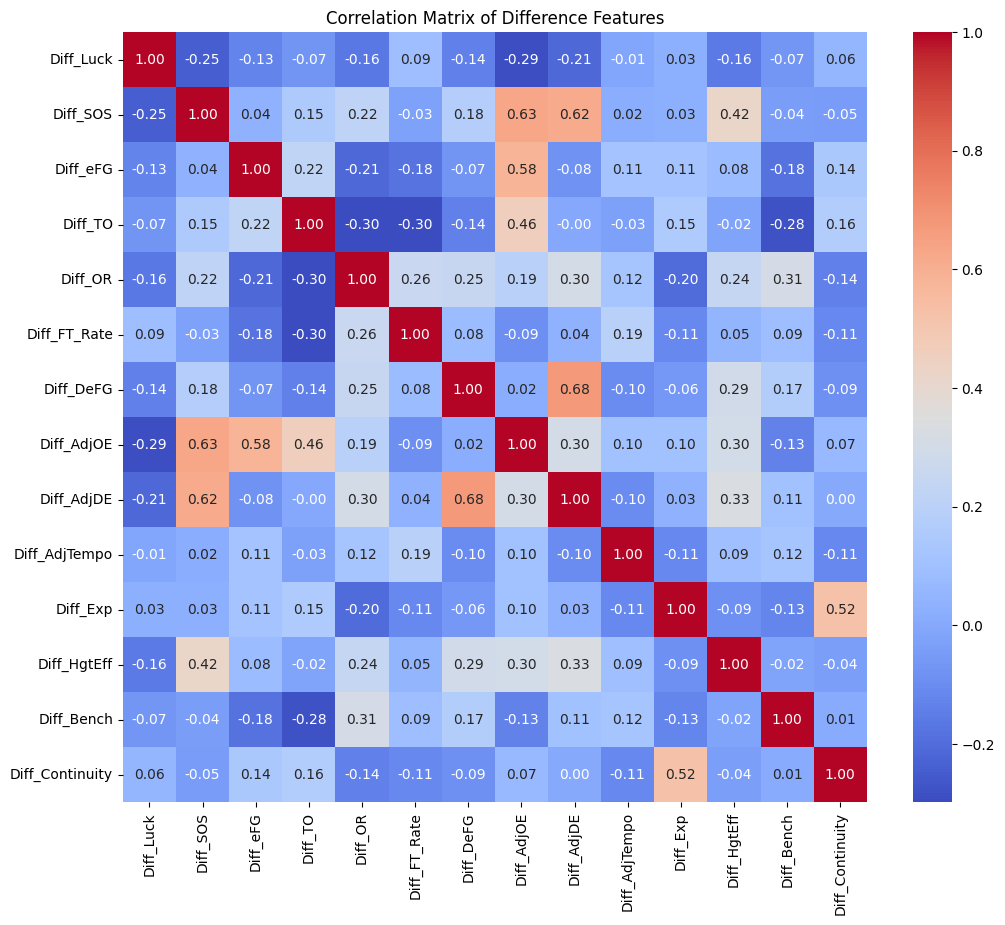

In [57]:
# re-checking for co-linearity based on selected features
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Difference Features")
plt.show()

No longer any features that are concerningly highly correlated

## Preparing Data for Modeling

- When initially modeling was conducted, there was data leakage from the input format
- Data was formatted as winner vs. loser and upset could be detected
- Instead formatting as higher v. lower seed below

In [58]:
# favorite vs. underdog instead of winner v. loser 
matchups_reframed = matchups_df.copy()

# Identify which team is the favorite (lower seed number = better seed)
fav_is_winner = matchups_reframed["WSeed"] <= matchups_reframed["LSeed"]

# Underdog stats minus Favorite stats
for col in features:
    w_col = col.replace("Diff_", "W_Rank").replace("Diff_", "")
    # flipping sign when favorite is the winner to get underdog minus favorite
    matchups_reframed[col] = np.where(fav_is_winner, -matchups_df[col], matchups_df[col])

# adding in favorite and underdog seed and team name for reference
matchups_reframed["Fav_Seed"] = np.where(fav_is_winner, matchups_df["WSeed"], matchups_df["LSeed"])
matchups_reframed["Dog_Seed"] = np.where(fav_is_winner, matchups_df["LSeed"], matchups_df["WSeed"])
matchups_reframed["Fav_Team"] = np.where(fav_is_winner, matchups_df["WTeamName"], matchups_df["LTeamName"])
matchups_reframed["Dog_Team"] = np.where(fav_is_winner, matchups_df["LTeamName"], matchups_df["WTeamName"])
matchups_reframed["SeedDiff"] = matchups_reframed["Dog_Seed"] - matchups_reframed["Fav_Seed"]

# Target: did the underdog win? (= upset)
matchups_reframed["Upset"] = matchups_df["Upset"]

# Add SeedDiff as a feature
features_with_seed = features + ["SeedDiff"]
matchups_reframed["SeedDiff"] = matchups_reframed["Dog_Seed"] - matchups_reframed["Fav_Seed"]
X = matchups_reframed[features_with_seed]
y = matchups_reframed["Upset"]

# Means should be mainly positive since we are doing underdog minus favorite (lower rank --> better)
print(X.mean().round(2))
print(f"\nUpset rate: {y.mean():.2%}")

Diff_Luck          -5.49
Diff_SOS           68.71
Diff_eFG           27.88
Diff_TO            28.12
Diff_OR            40.03
Diff_FT_Rate       -0.62
Diff_DeFG          34.30
Diff_AdjOE         44.89
Diff_AdjDE         42.79
Diff_AdjTempo       9.11
Diff_Exp            0.63
Diff_HgtEff        48.31
Diff_Bench         -9.58
Diff_Continuity    -0.93
SeedDiff            6.28
dtype: float64

Upset rate: 22.39%


Subsetting for just Underdogs (seed diff more than 1)

In [59]:
underdogs = matchups_reframed[matchups_reframed["SeedDiff"].abs() > 1].copy()

print(f"\nTotal matchups: {len(matchups_reframed)}")
print(f"Underdog matchups (|SeedDiff| > 1): {len(underdogs)}")
print(f"Upsets: {(underdogs['Upset'] == 1).sum()}  |  Non-Upsets: {(underdogs['Upset'] == 0).sum()}")


Total matchups: 902
Underdog matchups (|SeedDiff| > 1): 728
Upsets: 202  |  Non-Upsets: 526


## Upset vs. Non-Upset Differences

In [60]:
upset_games = underdogs.loc[underdogs["Upset"] == 1, features_with_seed]
non_upset_games = underdogs.loc[underdogs["Upset"] == 0, features_with_seed]

# gathering summary statistics for upsets vs. non
summary_upset = upset_games.describe().T[["mean", "50%", "std"]]
summary_non_upset = non_upset_games.describe().T[["mean", "50%", "std"]]

summary_upset.columns  = ["Upset_Mean", "Upset_Median", "Upset_Std"]
summary_non_upset.columns = ["NonUpset_Mean", "NonUpset_Median", "NonUpset_Std"]

# adding seed diff
comparison = pd.concat([summary_upset, summary_non_upset], axis=1)
comparison["Mean_Diff"] = comparison["Upset_Mean"] - comparison["NonUpset_Mean"]

print("\n── Profile Comparison: Upset vs Non-Upset Underdogs ──")
print(comparison.round(2).to_string())


── Profile Comparison: Upset vs Non-Upset Underdogs ──
                 Upset_Mean  Upset_Median  Upset_Std  NonUpset_Mean  NonUpset_Median  NonUpset_Std  Mean_Diff
Diff_Luck            -13.06          -7.0     133.61          -7.23            -11.5        125.92      -5.83
Diff_SOS              33.51          13.0      80.90         103.77             76.0        108.05     -70.26
Diff_eFG              17.52          16.5     110.88          37.29             29.0        110.32     -19.77
Diff_TO                9.00          -1.0     114.62          40.01             31.0        117.07     -31.01
Diff_OR               25.69          26.0     131.90          54.72             49.0        127.97     -29.02
Diff_FT_Rate          18.08          11.5     125.77          -7.59            -12.0        131.11      25.67
Diff_DeFG             19.11          13.0      95.08          47.46             38.0         94.25     -28.35
Diff_AdjOE            25.80          20.0      55.27          64

The biggest differences between upsets and non-upsets are
- Strength of Schedule: Teams that upset have an average of 70 ranks harder SOS than non-upset teams
- Adjusted Defensive Efficiency: Teams that upset have an average of 47 ranks higher adjusted defensive efficiency than non-upset teams
- Bench Utilization: Teams that upset use their bench an average of 36 ranks less than non-upset teams
- Turnover Difference: Teams that upset are ranked 31 slots higher, on average, in turnover differential than non-upset teams
- Teams that upset are approximately 2 seeds higher, on average, than non-upset teams

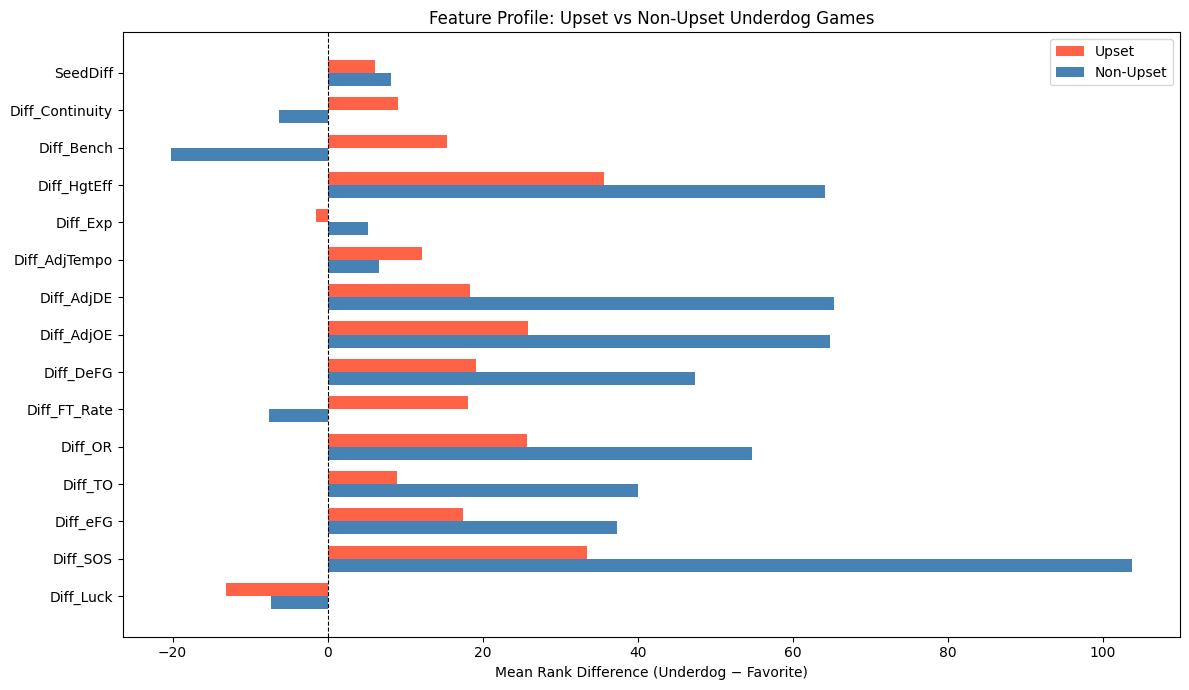

In [61]:
# Bar chart: side-by-side means
fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(features_with_seed))
width = 0.35
ax.barh([i + width/2 for i in x], comparison["Upset_Mean"], width, label="Upset", color="tomato")
ax.barh([i - width/2 for i in x], comparison["NonUpset_Mean"], width, label="Non-Upset", color="steelblue")
ax.set_yticks(list(x))
ax.set_yticklabels(features_with_seed)
ax.set_xlabel("Mean Rank Difference (Underdog − Favorite)")
ax.set_title("Feature Profile: Upset vs Non-Upset Underdog Games")
ax.legend()
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

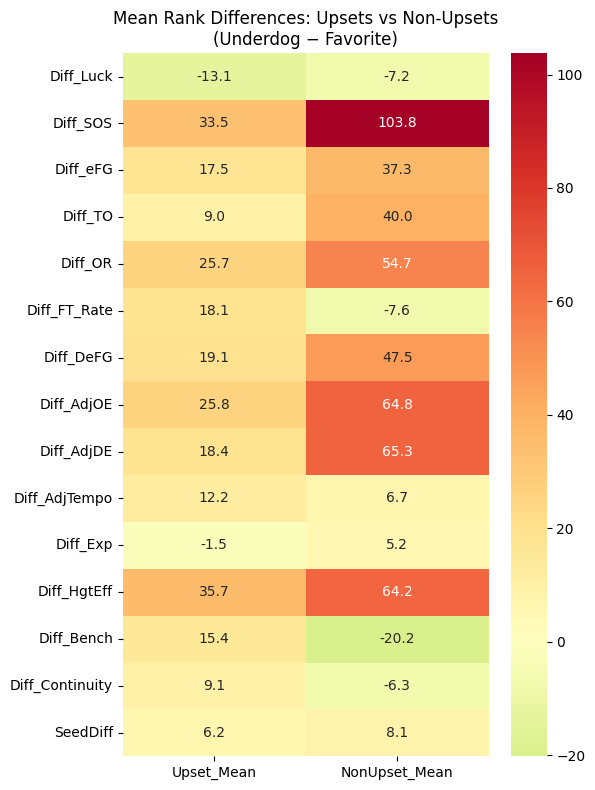

In [62]:
# Heatmap of means
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(
    comparison[["Upset_Mean", "NonUpset_Mean"]],
    annot=True, fmt=".1f", cmap="RdYlGn_r", center=0, ax=ax
)
ax.set_title("Mean Rank Differences: Upsets vs Non-Upsets\n(Underdog − Favorite)")
plt.tight_layout()
plt.show()

## Modeling

- Add seed difference for clustering
- See which cluster teams from this year would fall into, where were upsets? (maybe, would need new data)
- Arrive at a definitive conclusion with a strong visualization

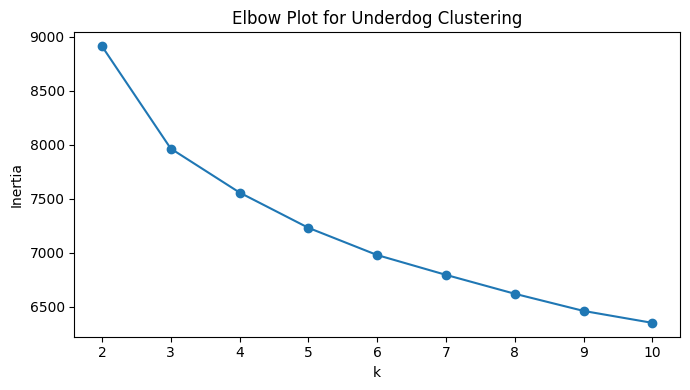


── Cluster Upset Rates ──
 Cluster  n_games  n_upsets  upset_rate  upset_rate_pct
       0      170        60    0.352941            35.3
       1      196        75    0.382653            38.3
       2      104        14    0.134615            13.5
       3      156        47    0.301282            30.1
       4      102         6    0.058824             5.9


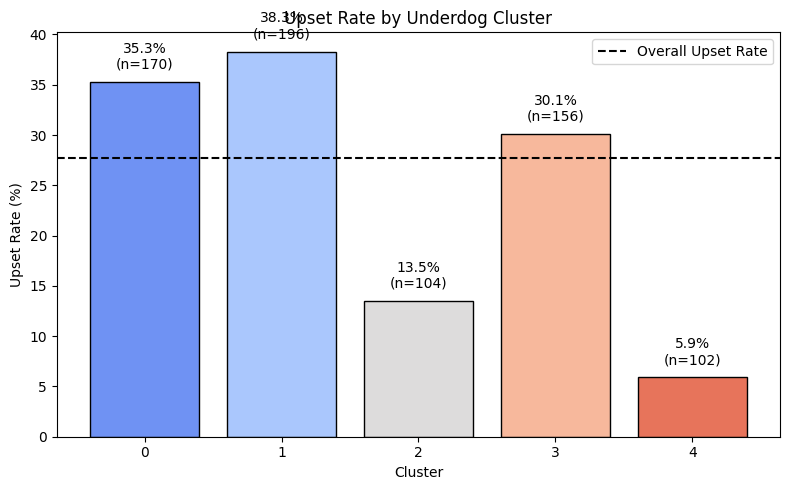

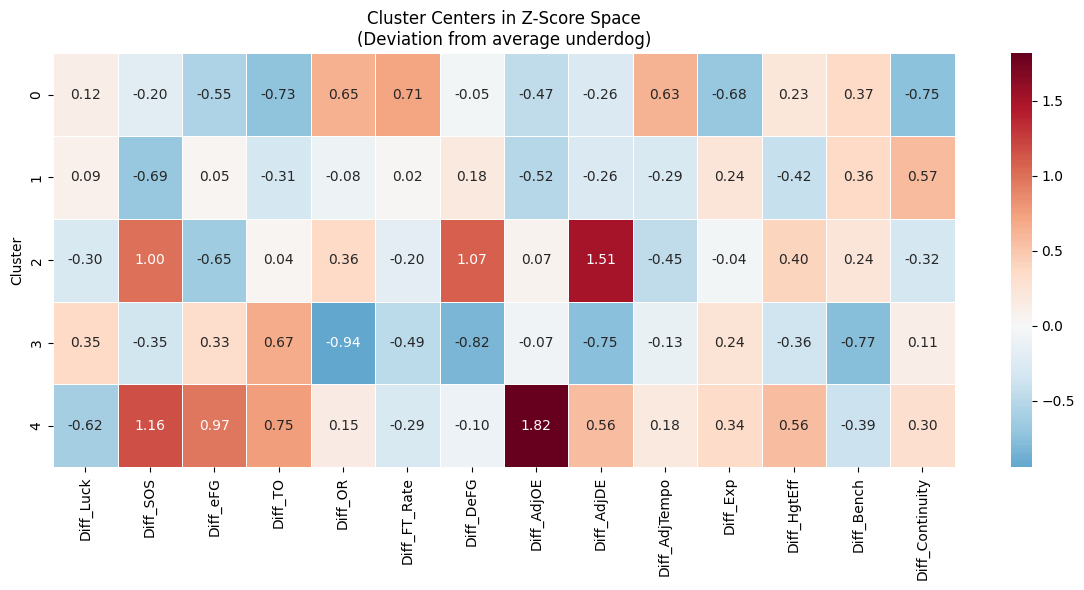


── Cluster Centers (Underdog − Favorite, Original Scale) ──
         Diff_Luck  Diff_SOS  Diff_eFG  Diff_TO  Diff_OR  Diff_FT_Rate  Diff_DeFG  Diff_AdjOE  Diff_AdjDE  Diff_AdjTempo  Diff_Exp  Diff_HgtEff  Diff_Bench  Diff_Continuity
Cluster                                                                                                                                                                     
0             6.67     63.16    -28.98   -54.28   130.79         92.29      34.99       20.21       33.28         102.32    -82.84        85.91       39.98          -103.51
1             3.17     11.37     37.16    -5.01    35.94          2.58      56.46       16.32       33.09         -36.07     33.52         1.94       39.33            75.55
2           -46.70    190.19    -39.62    35.64    93.40        -25.92     141.76       58.87      161.60         -59.78     -1.70       108.60       22.42           -45.65
3            36.03     47.65     68.38   110.01   -75.53        -63.64    

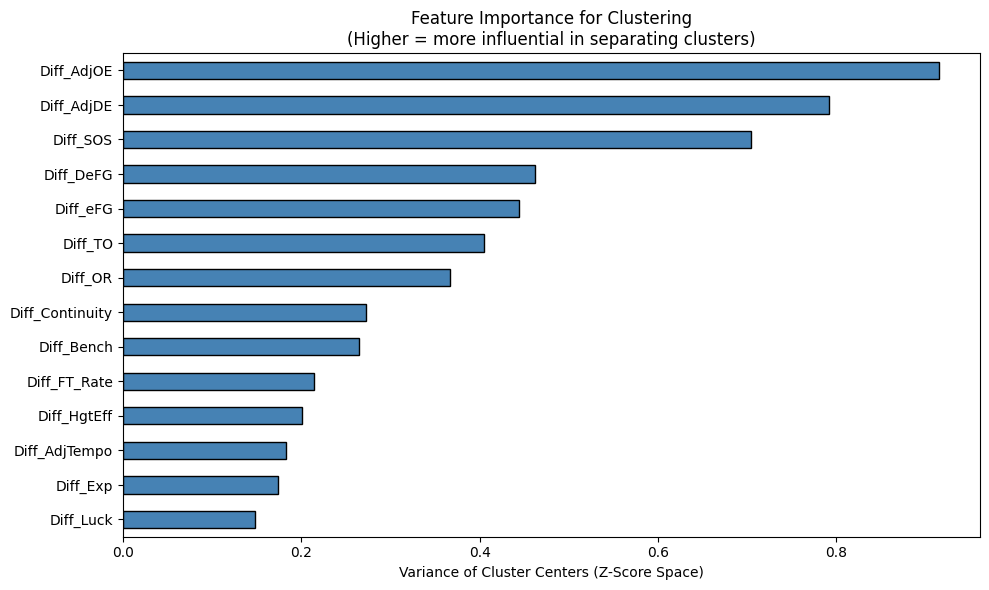


── Feature Importance (Variance of Centers) ──
Diff_AdjOE         0.9151
Diff_AdjDE         0.7919
Diff_SOS           0.7040
Diff_DeFG          0.4624
Diff_eFG           0.4437
Diff_TO            0.4044
Diff_OR            0.3669
Diff_Continuity    0.2724
Diff_Bench         0.2652
Diff_FT_Rate       0.2145
Diff_HgtEff        0.2007
Diff_AdjTempo      0.1825
Diff_Exp           0.1736
Diff_Luck          0.1478

── Top 5 Defining Features Per Cluster ──

Cluster 0 (n=170, upset rate=35.3%):
  ↓ Diff_Continuity: -0.75
  ↓ Diff_TO: -0.73
  ↑ Diff_FT_Rate: 0.71
  ↓ Diff_Exp: -0.68
  ↑ Diff_OR: 0.65

Cluster 1 (n=196, upset rate=38.3%):
  ↓ Diff_SOS: -0.69
  ↑ Diff_Continuity: 0.57
  ↓ Diff_AdjOE: -0.52
  ↓ Diff_HgtEff: -0.42
  ↑ Diff_Bench: 0.36

Cluster 2 (n=104, upset rate=13.5%):
  ↑ Diff_AdjDE: 1.51
  ↑ Diff_DeFG: 1.07
  ↑ Diff_SOS: 1.00
  ↓ Diff_eFG: -0.65
  ↓ Diff_AdjTempo: -0.45

Cluster 3 (n=156, upset rate=30.1%):
  ↓ Diff_OR: -0.94
  ↓ Diff_DeFG: -0.82
  ↓ Diff_Bench: -0.77
  ↓ Dif

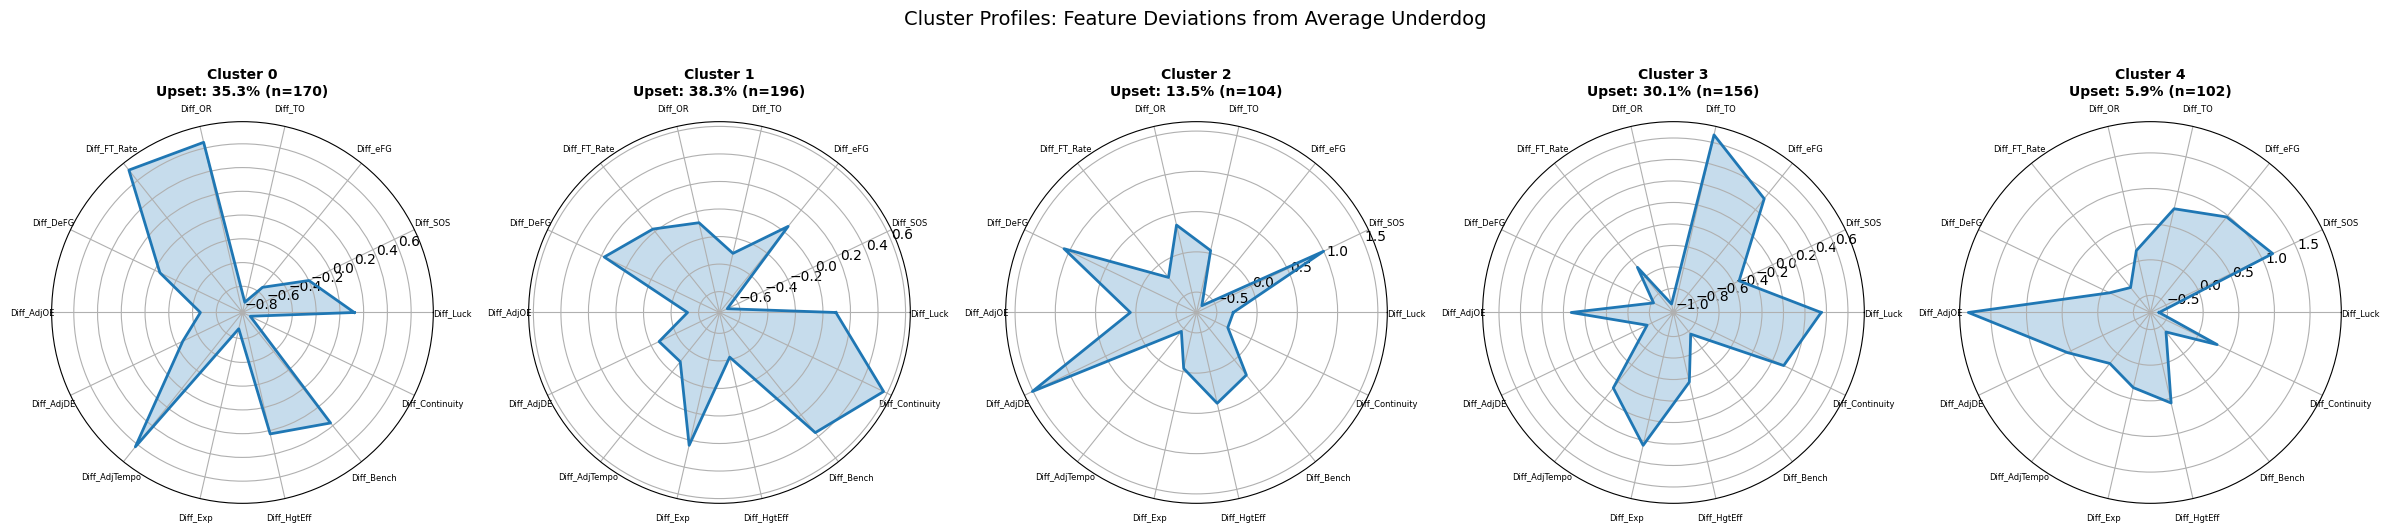

In [63]:
# clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(underdogs[features])

# Elbow plot
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Plot for Underdog Clustering")
plt.tight_layout()
plt.show()

# Fit with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
underdogs["Cluster"] = kmeans.fit_predict(X_scaled)

# Cluster upset rates
cluster_summary = underdogs.groupby("Cluster").agg(
    n_games=("Upset", "count"),
    n_upsets=("Upset", "sum"),
    upset_rate=("Upset", "mean")
).reset_index()
cluster_summary["upset_rate_pct"] = (cluster_summary["upset_rate"] * 100).round(1)

print("\n── Cluster Upset Rates ──")
print(cluster_summary.to_string(index=False))

# Bar chart: upset rate by cluster
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    cluster_summary["Cluster"].astype(str),
    cluster_summary["upset_rate_pct"],
    color=sns.color_palette("coolwarm", 5),
    edgecolor="black"
)
for bar, n, pct in zip(bars, cluster_summary["n_games"], cluster_summary["upset_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{pct}%\n(n={n})", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Cluster")
ax.set_ylabel("Upset Rate (%)")
ax.set_title("Upset Rate by Underdog Cluster")
ax.axhline(underdogs["Upset"].mean() * 100, color="black", linestyle="--", label="Overall Upset Rate")
ax.legend()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# STEP 5: FEATURE IMPORTANCE & CLUSTER PROFILES
# ═══════════════════════════════════════════════════════════════════

# ── 5a. Cluster centers in z-score space ──
cluster_zscores = pd.DataFrame(kmeans.cluster_centers_, columns=features)
cluster_zscores.index.name = "Cluster"

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    cluster_zscores, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, ax=ax, linewidths=0.5
)
ax.set_title("Cluster Centers in Z-Score Space\n(Deviation from average underdog)")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

# ── 5b. Cluster centers in original scale ──
cluster_profiles = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
).round(2)
cluster_profiles.index.name = "Cluster"

print("\n── Cluster Centers (Underdog − Favorite, Original Scale) ──")
print(cluster_profiles.to_string())

# ── 5c. Overall feature importance: variance across cluster centers ──
center_variance = cluster_zscores.var(axis=0).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
center_variance.plot.barh(ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Variance of Cluster Centers (Z-Score Space)")
ax.set_title("Feature Importance for Clustering\n(Higher = more influential in separating clusters)")
plt.tight_layout()
plt.show()

print("\n── Feature Importance (Variance of Centers) ──")
print(center_variance.sort_values(ascending=False).round(4).to_string())

# ── 5d. Top 5 defining features per cluster ──
print("\n── Top 5 Defining Features Per Cluster ──")
for cid in range(kmeans.n_clusters):
    row = cluster_zscores.loc[cid]
    top = row.abs().sort_values(ascending=False).head(5)
    print(f"\nCluster {cid} (n={cluster_summary.loc[cid, 'n_games']}, "
          f"upset rate={cluster_summary.loc[cid, 'upset_rate_pct']}%):")
    for feat in top.index:
        direction = "↑" if row[feat] > 0 else "↓"
        print(f"  {direction} {feat}: {row[feat]:.2f}")

# ── 5e. Radar charts per cluster ──
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(24, 5), subplot_kw=dict(polar=True))
for cid, ax in enumerate(axes):
    values = cluster_zscores.loc[cid].values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, size=6)
    ax.set_title(
        f"Cluster {cid}\n"
        f"Upset: {cluster_summary.loc[cid, 'upset_rate_pct']}% "
        f"(n={cluster_summary.loc[cid, 'n_games']})",
        size=10, fontweight="bold"
    )
plt.suptitle("Cluster Profiles: Feature Deviations from Average Underdog",
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()